## **Music Recommendation Algorithm Project**
</br>
Info here

***Exploratory Data Analysis***

Details

---
### **1. Imports**

In [1]:
# Importing sys to ensure proper environment setup
import sys

print(sys.version_info)

sys.version_info(major=3, minor=11, micro=14, releaselevel='final', serial=0)


In [2]:
# Importing pandas and numpy for numerical analysis
# Importing pyplot and seaborn to visualize the data
# Importing os, pathlib, and warnings for functionality, faster loading, flagging exceptions, etc.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import ticker
import seaborn as sns
import os # possibly remove
from pathlib import Path, PureWindowsPath
from scipy.stats import trim_mean
import warnings
warnings.filterwarnings('ignore')

# Makes graphs appear in line
%matplotlib inline

sns.set(style="whitegrid", palette="muted", font_scale=1.25)

print("Setup Complete")

Setup Complete


---
### **2. Data Loading & Preliminary Exploration**

In [3]:
# Explicitly noting path as being in Windows format to avoid issues with backsplash
#filename = PureWindowsPath("..Data\tcc_ceds_music.csv")

# Convert path to the correct format
#file_path = Path(filename)
file = open("C:\\Users\\winni\\music-rec-algo\\Data\\tcc_ceds_music.csv")

# Loading data as a DataFrame
df = pd.read_csv(file) 

# Using head() function to display the first five rows of the data
print("Heads")
print(df.head())

print()

# Using tail() function to display the last five rows of the data
print("Tails")
print(df.tail())

Heads
   Unnamed: 0           artist_name            track_name  release_date genre  \
0           0                mukesh  mohabbat bhi jhoothi          1950   pop   
1           4         frankie laine             i believe          1950   pop   
2           6           johnnie ray                   cry          1950   pop   
3          10           pérez prado              patricia          1950   pop   
4          12  giorgos papadopoulos    apopse eida oneiro          1950   pop   

                                              lyrics  len    dating  violence  \
0  hold time feel break feel untrue convince spea...   95  0.000598  0.063746   
1  believe drop rain fall grow believe darkest ni...   51  0.035537  0.096777   
2  sweetheart send letter goodbye secret feel bet...   24  0.002770  0.002770   
3  kiss lips want stroll charm mambo chacha merin...   54  0.048249  0.001548   
4  till darling till matter know till dream live ...   48  0.001350  0.001350   

   world/life  ...  

In [4]:
# Using shape() function to return a tuple listing number of rows and columns in the data

print("Shape:", df.shape)

Shape: (28372, 31)


In [5]:
# Using info() function to view column names, data types, and other relevant information

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28372 entries, 0 to 28371
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed: 0                28372 non-null  int64  
 1   artist_name               28372 non-null  object 
 2   track_name                28372 non-null  object 
 3   release_date              28372 non-null  int64  
 4   genre                     28372 non-null  object 
 5   lyrics                    28372 non-null  object 
 6   len                       28372 non-null  int64  
 7   dating                    28372 non-null  float64
 8   violence                  28372 non-null  float64
 9   world/life                28372 non-null  float64
 10  night/time                28372 non-null  float64
 11  shake the audience        28372 non-null  float64
 12  family/gospel             28372 non-null  float64
 13  romantic                  28372 non-null  float64
 14  commun

In [6]:
# Using describe() function to view summary statistics of data and round() for output

df.describe().round(4)

,Unnamed: 0,release_date,len,dating,violence,world/life,night/time,shake the audience,family/gospel,romantic,...,like/girls,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,age
count,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,...,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000,28372.0000
mean,42946.3236,1990.2369,73.0284,0.0211,0.1184,0.1210,0.0574,0.0174,0.0170,0.0487,...,0.0281,0.1294,0.0310,0.5333,0.6652,0.3392,0.0800,0.5329,0.5699,0.4252
std,24749.3255,18.4875,41.8298,0.0524,0.1787,0.1722,0.1119,0.0407,0.0420,0.1061,...,0.0585,0.1811,0.0717,0.1732,0.1084,0.3267,0.2112,0.2510,0.2444,0.2641
min,0.0000,1950.0000,1.0000,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,0.0003,...,0.0003,0.0003,0.0003,0.0054,0.0000,0.0000,0.0000,0.0000,0.0000,0.0143
25%,20391.2500,1975.0000,42.0000,0.0009,0.0011,0.0012,0.0010,0.0010,0.0009,0.0010,...,0.0010,0.0011,0.0010,0.4130,0.5954,0.0342,0.0000,0.3291,0.3804,0.1857
50%,45405.5000,1991.0000,63.0000,0.0015,0.0025,0.0066,0.0019,0.0016,0.0015,0.0018,...,0.0016,0.0053,0.0018,0.5386,0.6791,0.2259,0.0001,0.5394,0.5806,0.4143
75%,64090.5000,2007.0000,93.0000,0.0040,0.1926,0.1978,0.0658,0.0100,0.0048,0.0423,...,0.0266,0.2351,0.0326,0.6567,0.7490,0.6325,0.0093,0.7383,0.7728,0.6429
max,82451.0000,2019.0000,199.0000,0.6477,0.9818,0.9621,0.9737,0.4975,0.5453,0.9408,...,0.5945,0.9814,0.9588,0.9935,1.0000,1.0000,0.9970,1.0000,1.0000,1.0000


In [8]:
# Updating column names to remove whitespace and erroroneous characters
df.columns = df.columns.str.strip().str.replace(' ', '_').str.replace('(', '').str.replace(':', '')
df.columns = df.columns.str.replace(')', '').str.replace('-', '_').str.replace('/', '_')
print("Updated Column Names:", df.columns)
print(df.info())

Updated Column Names: Index(['Unnamed_0', 'artist_name', 'track_name', 'release_date', 'genre',
       'lyrics', 'len', 'dating', 'violence', 'world_life', 'night_time',
       'shake_the_audience', 'family_gospel', 'romantic', 'communication',
       'obscene', 'music', 'movement_places', 'light_visual_perceptions',
       'family_spiritual', 'like_girls', 'sadness', 'feelings', 'danceability',
       'loudness', 'acousticness', 'instrumentalness', 'valence', 'energy',
       'topic', 'age'],
      dtype='object')
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28372 entries, 0 to 28371
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Unnamed_0                 28372 non-null  int64  
 1   artist_name               28372 non-null  object 
 2   track_name                28372 non-null  object 
 3   release_date              28372 non-null  int64  
 4   genre                     28372 non

---
### **3. Initial Visualizations**

Prior to creating visualizations, it's important to get an understanding of the dataset:    
#### **<p style="text-align:center;">Genres</p>**    
● **blues:** name of the artist    
● **country:** name of the song    
● **hip hop:** when the song was released    
● **jazz:** categorical genre of the song    
● **pop:** pre-tokenized lyrics of the song    
● **reggae:** number of words in the lyrics of the song    
● **rock:** number of words in the lyrics of the song    

#### **<p style="text-align:center;">Selected Features</p>**    
● **Acousticness:** presence of acoustic instruments <br>
● **Danceability:** how suitable a track is for dancing based on a combination of musical elements including tempo, rhythem stability, beat strength, & overall regularity <br>
● **Loudness:** the average loudness in decibels (dB) across the entire track <br>
● **Instrumentalness:** a high value describes whether a track contains fewer vocals <br>
● **Valence:** High (low) values means that the track is more happy, euphoring (sad, angry) <br> 
● **Energy:** measures intensity & activity of music; energetic tracks will be fast, loud & noisy <br>

#### **<p style="text-align:center;">Column Descriptions</p>**     
● **artist_name:** name of the artist <br>
● **track_name:** name of the song <br>
● **release_date:** when the song was released <br>
● **genre:** categorical genre of the song <br>
● **lyrics:** pre-tokenized lyrics of the song <br> 
● **len:** number of words in the lyrics of the song <br>
● **dating:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with dating <br>
● **violence:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with violence <br> 
● **world/life:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with the world or life in general terms <br>
● **night/time:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with night-life or time <br>
● **shake the audience:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with provacative feeling <br>
● **family/gospel:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with family-oriented content or the gospel <br>
● **romantic:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with romantic feeling <br>
● **communication:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with communication (either in romantic terms or otherwise) <br> 
● **obscene:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with obscene content (money, rockstar-lifestyle, etc) <br>
● **music:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with music (music about music, basically) <br>
● **movement/places:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with movement or various locations <br> 
● **light/visual perceptions:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with the sun or other physical weather-related patterns <br>
● **family/spiritual:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with the importance of family or spirituality <br>
● **sadness:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with ABCDEFG  <br>
● **feelings:** a score from 0 to 1 expressing how likely it is that this song's lyrics have something to do with emotions, either positive or negative <br>
● **topic:** categorical label of lyrical content <br>
● **age:** a score from 0 to 1 expressing how "old" a song is from our perspective; 1 being the oldest, 0 being the newest <br> 

In [9]:
# Sample 25% of data used to ensure visualizations worked
sr = df.sample(frac=0.25)

# Verify number of rows
print(f"Original rows: {len(df)}")
print(f"Samples rows (25%): {len(sr)}")

# Displaying result
sr

Original rows: 28372
Samples rows (25%): 7093


,Unnamed_0,artist_name,track_name,release_date,genre,lyrics,len,dating,violence,world_life,...,sadness,feelings,danceability,loudness,acousticness,instrumentalness,valence,energy,topic,age
20577,62423,mocky,whistlin,2015,jazz,wear dark hoddie warm dark soul black woah woa...,140,0.000786,0.410341,0.000786,...,0.000786,0.000786,0.571104,0.647925,0.585341,0.367409,0.561006,0.436419,violence,0.071429
11392,34330,hank locklin,send me the pillow you dream on,2003,country,send pillow dream know care send pillow dream ...,45,0.001316,0.001316,0.001316,...,0.001316,0.001316,0.577602,0.616132,0.843373,0.000004,0.618714,0.308287,romantic,0.242857
9951,29120,warren zevon,reconsider me,1987,country,need come run reconsider reconsider past make ...,43,0.045568,0.001754,0.304983,...,0.001754,0.001754,0.502870,0.594031,0.210843,0.000285,0.462077,0.628617,world/life,0.471429
17391,54966,dave brubeck,one song,1957,jazz,young court girls play wait game maid refuse t...,103,0.000741,0.000741,0.361047,...,0.000741,0.000741,0.579768,0.507294,0.921687,0.002814,0.682605,0.151125,world/life,0.900000
4825,13998,sam cooke,it's all right,2000,pop,whoa right right right right long know long kn...,64,0.077220,0.000835,0.000835,...,0.000835,0.017413,0.380483,0.723688,0.758032,0.000000,0.605317,0.501486,night/time,0.285714
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5658,16294,me first and the gimme gimmes,country roads,2008,pop,heaven blue ridge mountains shenandoah river l...,70,0.001053,0.001053,0.038014,...,0.001053,0.018367,0.401061,0.766454,0.000023,0.000000,0.581616,0.935934,music,0.171429
14938,47692,the gories,nitroglycerine,1991,blues,time cause grief blow hatred mind reach fall s...,82,0.000907,0.584761,0.000907,...,0.071738,0.064549,0.326329,0.533805,0.018674,0.000115,0.567189,0.902900,violence,0.414286
16043,51204,buddy guy,too many tears,2008,blues,know lead clue things tangle mean hurt baby st...,81,0.034523,0.000774,0.059679,...,0.752973,0.000774,0.299253,0.797118,0.154618,0.000000,0.764015,0.815810,sadness,0.171429
902,2402,the beach boys,good to my baby (stereo),1965,pop,good baby good baby good baby good baby think ...,68,0.364009,0.000774,0.000774,...,0.000774,0.307413,0.481209,0.717586,0.523092,0.000000,0.971146,0.821816,feelings,0.785714


In [10]:
# Unique values in each column
def unique_values(df):
    for column in df.columns:
        unique_vals = df[column].unique()
        print(f"Unique values in '{column}': {unique_vals}\n")

# ALTERNATIVE
def unique_values(df):
    unique_values = []
    col_name = []
    null_values = []
    for col in df.columns:
        unique_values.append(df[col].nunique())
        col_name.append(col)
        null_values.append(df[col].isna().any())
    df_dict = {
        'Features' : col_name,
        'Unique values' : unique_values,
        'Contains Null' : null_values
    }
    return pd.DataFrame(df_dict, columns=['Features','Unique values','Contains Null'])

unique_values_songs = unique_values(df)
print(unique_values_songs)

                    Features  Unique values  Contains Null
0                  Unnamed_0          28372          False
1                artist_name           5426          False
2                 track_name          23689          False
3               release_date             70          False
4                      genre              7          False
5                     lyrics          28372          False
6                        len            199          False
7                     dating          27918          False
8                   violence          28189          False
9                 world_life          28195          False
10                night_time          28169          False
11        shake_the_audience          27161          False
12             family_gospel          28050          False
13                  romantic          27892          False
14             communication          28192          False
15                   obscene          28203          Fal

In [23]:
# Finding missing values and if relevant, consider altering or dropping
missing = df.isna().sum()
missing_pct = (missing / len(df) * 100).round(2)

pd.DataFrame({'count': missing, 'percent': missing_pct})

,count,percent
Unnamed_0,0,0.00
artist_name,28324,99.83
track_name,28332,99.86
release_date,0,0.00
genre,28372,100.00
lyrics,28372,100.00
len,0,0.00
dating,0,0.00
violence,0,0.00
world_life,0,0.00


---
### **4. Univariate Analysis**

In [11]:
# Reviewing data types of each column
df.dtypes

Unnamed_0                     int64
artist_name                  object
track_name                   object
release_date                  int64
genre                        object
lyrics                       object
len                           int64
dating                      float64
violence                    float64
world_life                  float64
night_time                  float64
shake_the_audience          float64
family_gospel               float64
romantic                    float64
communication               float64
obscene                     float64
music                       float64
movement_places             float64
light_visual_perceptions    float64
family_spiritual            float64
like_girls                  float64
sadness                     float64
feelings                    float64
danceability                float64
loudness                    float64
acousticness                float64
instrumentalness            float64
valence                     

List of Genres: [nan]
Count by Genre: Series([], Name: count, dtype: int64)


IndexError: index 0 is out of bounds for axis 0 with size 0

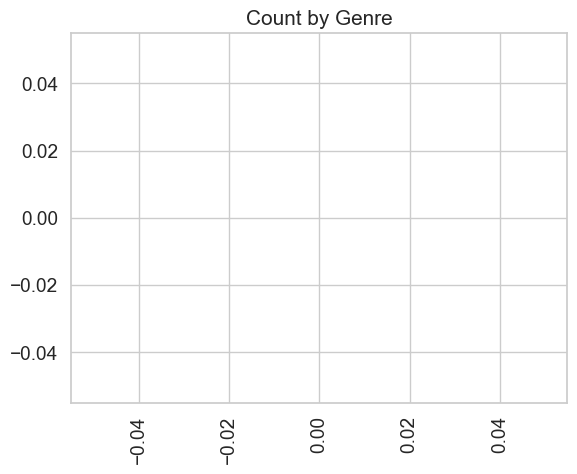

In [17]:
# List of genres
genres = df['genre'].unique()
print("List of Genres:", genres)

genres_count = df['genre'].value_counts()
print("Count by Genre:", genres_count)
genres_count.plot(kind='bar', title='Count by Genre')
plt.xlabel('Genre') 
plt.ylabel('Count')

plt.show()

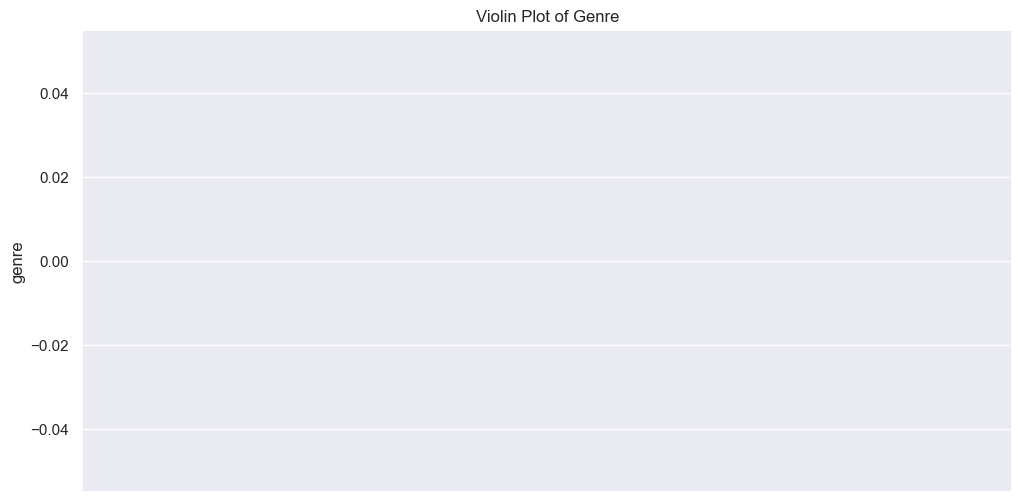

In [22]:
# Violinplot of genre
plt.figure(figsize=(12, 6))
sns.violinplot(df['genre'])
plt.title('Violin Plot of Genre')
plt.show()

List of Topics: ['sadness' 'world/life' 'music' 'romantic' 'violence' 'obscene'
 'night/time' 'feelings']
Count by Topic: topic
sadness       6096
violence      5710
world/life    5420
obscene       4882
music         2303
night/time    1825
romantic      1524
feelings       612
Name: count, dtype: int64


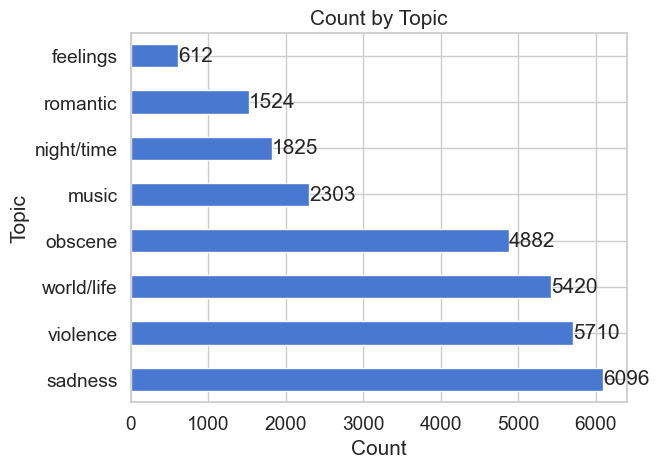

In [13]:
# List of topics
topics_1 = df['topic'].unique()
print("List of Topics:", topics_1)

# Count of each topic
topics_count = df['topic'].value_counts()
print("Count by Topic:", topics_count)

# Setting as DataFrame for later use
tf = pd.DataFrame(topics_count)
tf.reset_index(inplace=True)

# Bar plot of topic counts
topics_count.plot(kind='barh', title='Count by Topic')
plt.xlabel('Count') 
plt.ylabel('Topic')

# Adding annotations
for i, value in enumerate(topics_count):
    plt.text(value, i, str(value), va='center')

plt.show()

In [14]:
# Reviewing object types and changing if needed
for column in df.columns:
    if df[column].dtype == 'object':
        print(f"Column '{column}' has object type.")
        # Attempt to convert to numeric, coercing errors to NaN
        df[column] = pd.to_numeric(df[column], errors='coerce')

# Typecasting 'NAME' to category type +++++++++++++++++ troubleshoot w TA
# df['genre'] = df[''].astype('category')
# df['topic'] = df['topic'].astype('category')

# Confirming dtype conversion
print(df.dtypes)

Column 'artist_name' has object type.
Column 'track_name' has object type.
Column 'genre' has object type.
Column 'lyrics' has object type.
Column 'topic' has object type.
Unnamed_0                     int64
artist_name                 float64
track_name                  float64
release_date                  int64
genre                       float64
lyrics                      float64
len                           int64
dating                      float64
violence                    float64
world_life                  float64
night_time                  float64
shake_the_audience          float64
family_gospel               float64
romantic                    float64
communication               float64
obscene                     float64
music                       float64
movement_places             float64
light_visual_perceptions    float64
family_spiritual            float64
like_girls                  float64
sadness                     float64
feelings                    float64


---
### **5. Bivariate Analysis**    

Songs grouped by years; musical genres

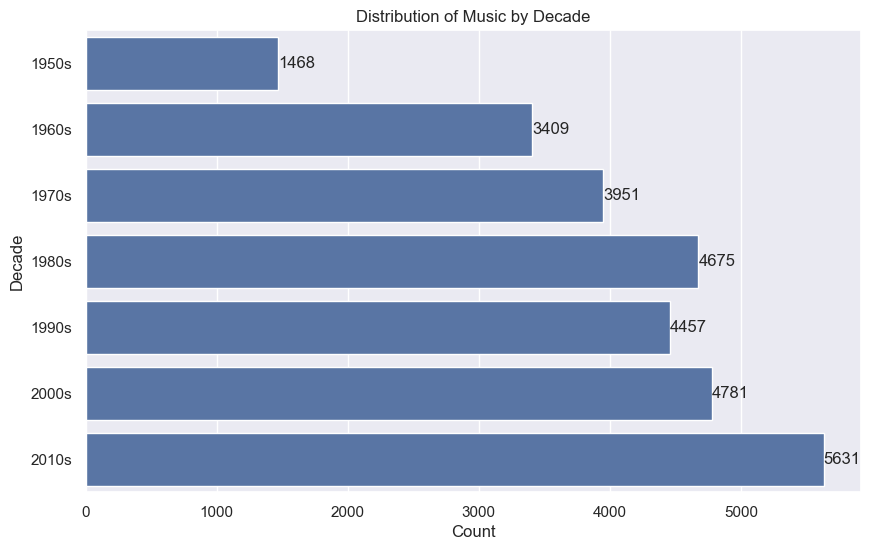

In [18]:
# Music By Time
def get_decade(year):
    period_start = int(year/10) * 10
    decade = '{}s'.format(period_start)
    return decade

df['decade'] = df['release_date'].apply(get_decade)
decade_counts = df['decade'].value_counts().sort_index()

sns.set(rc={'figure.figsize':(10,6)})
sns.countplot(df['decade'])
plt.title('Distribution of Music by Decade')
plt.xlabel('Count')
plt.ylabel('Decade')


# Adding annotations
for i, value in enumerate(decade_counts):
    plt.text(value, i, str(value), va='center')

plt.show()

Empty DataFrame
Columns: [genre, Unnamed_0]
Index: []


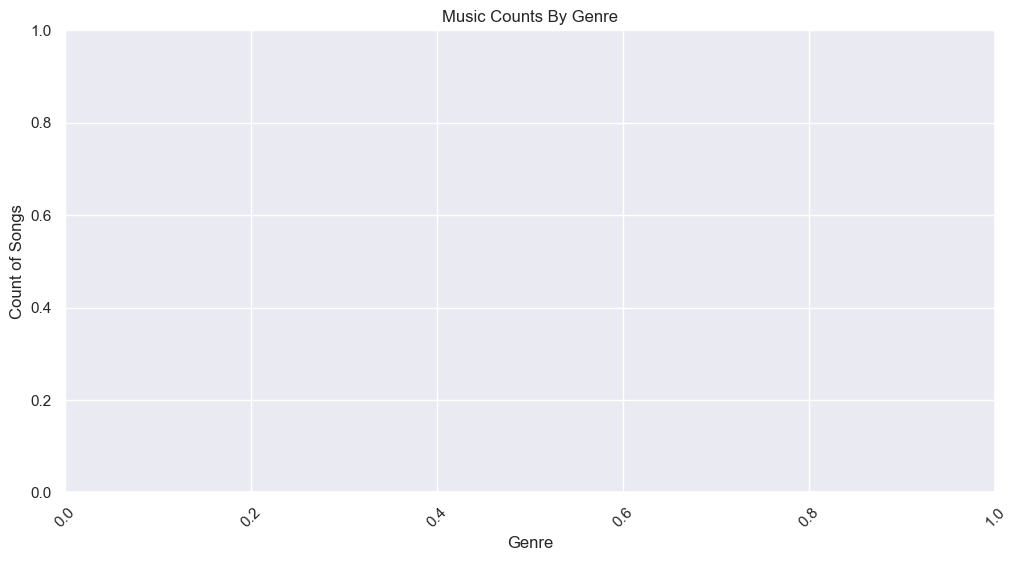

In [20]:
# Music Counts By Genre

music_by_genre = df.groupby('genre')['Unnamed_0'].count().reset_index()
print(music_by_genre)

# Utilitzing barplot
plt.figure(figsize=(12,6))
sns.barplot(x='genre', y='Unnamed_0', data=music_by_genre)
plt.title('Music Counts By Genre')
plt.xlabel('Genre')
plt.ylabel('Count of Songs')
plt.xticks(rotation=45)
plt.show()

---
### **6. Multivariate Analysis**    

Songs grouped by topic, genre, release date

---
### **7. Corralling Correlations**

In [24]:
# Finding initial relationships between columns in the dataset.
corr = df.corr(numeric_only=True).round(3)
print(corr)

                          Unnamed_0  artist_name  track_name  release_date  \
Unnamed_0                     1.000       -0.236      -0.034         0.331   
artist_name                  -0.236        1.000         NaN        -0.473   
track_name                   -0.034          NaN       1.000         0.010   
release_date                  0.331       -0.473       0.010         1.000   
genre                           NaN          NaN         NaN           NaN   
lyrics                          NaN          NaN         NaN           NaN   
len                           0.069       -0.007      -0.177         0.261   
dating                       -0.047       -0.062       0.173        -0.063   
violence                      0.141       -0.138      -0.081         0.138   
world_life                   -0.008        0.097       0.042        -0.042   
night_time                   -0.019        0.024       0.034        -0.023   
shake_the_audience            0.029        0.154       0.164    

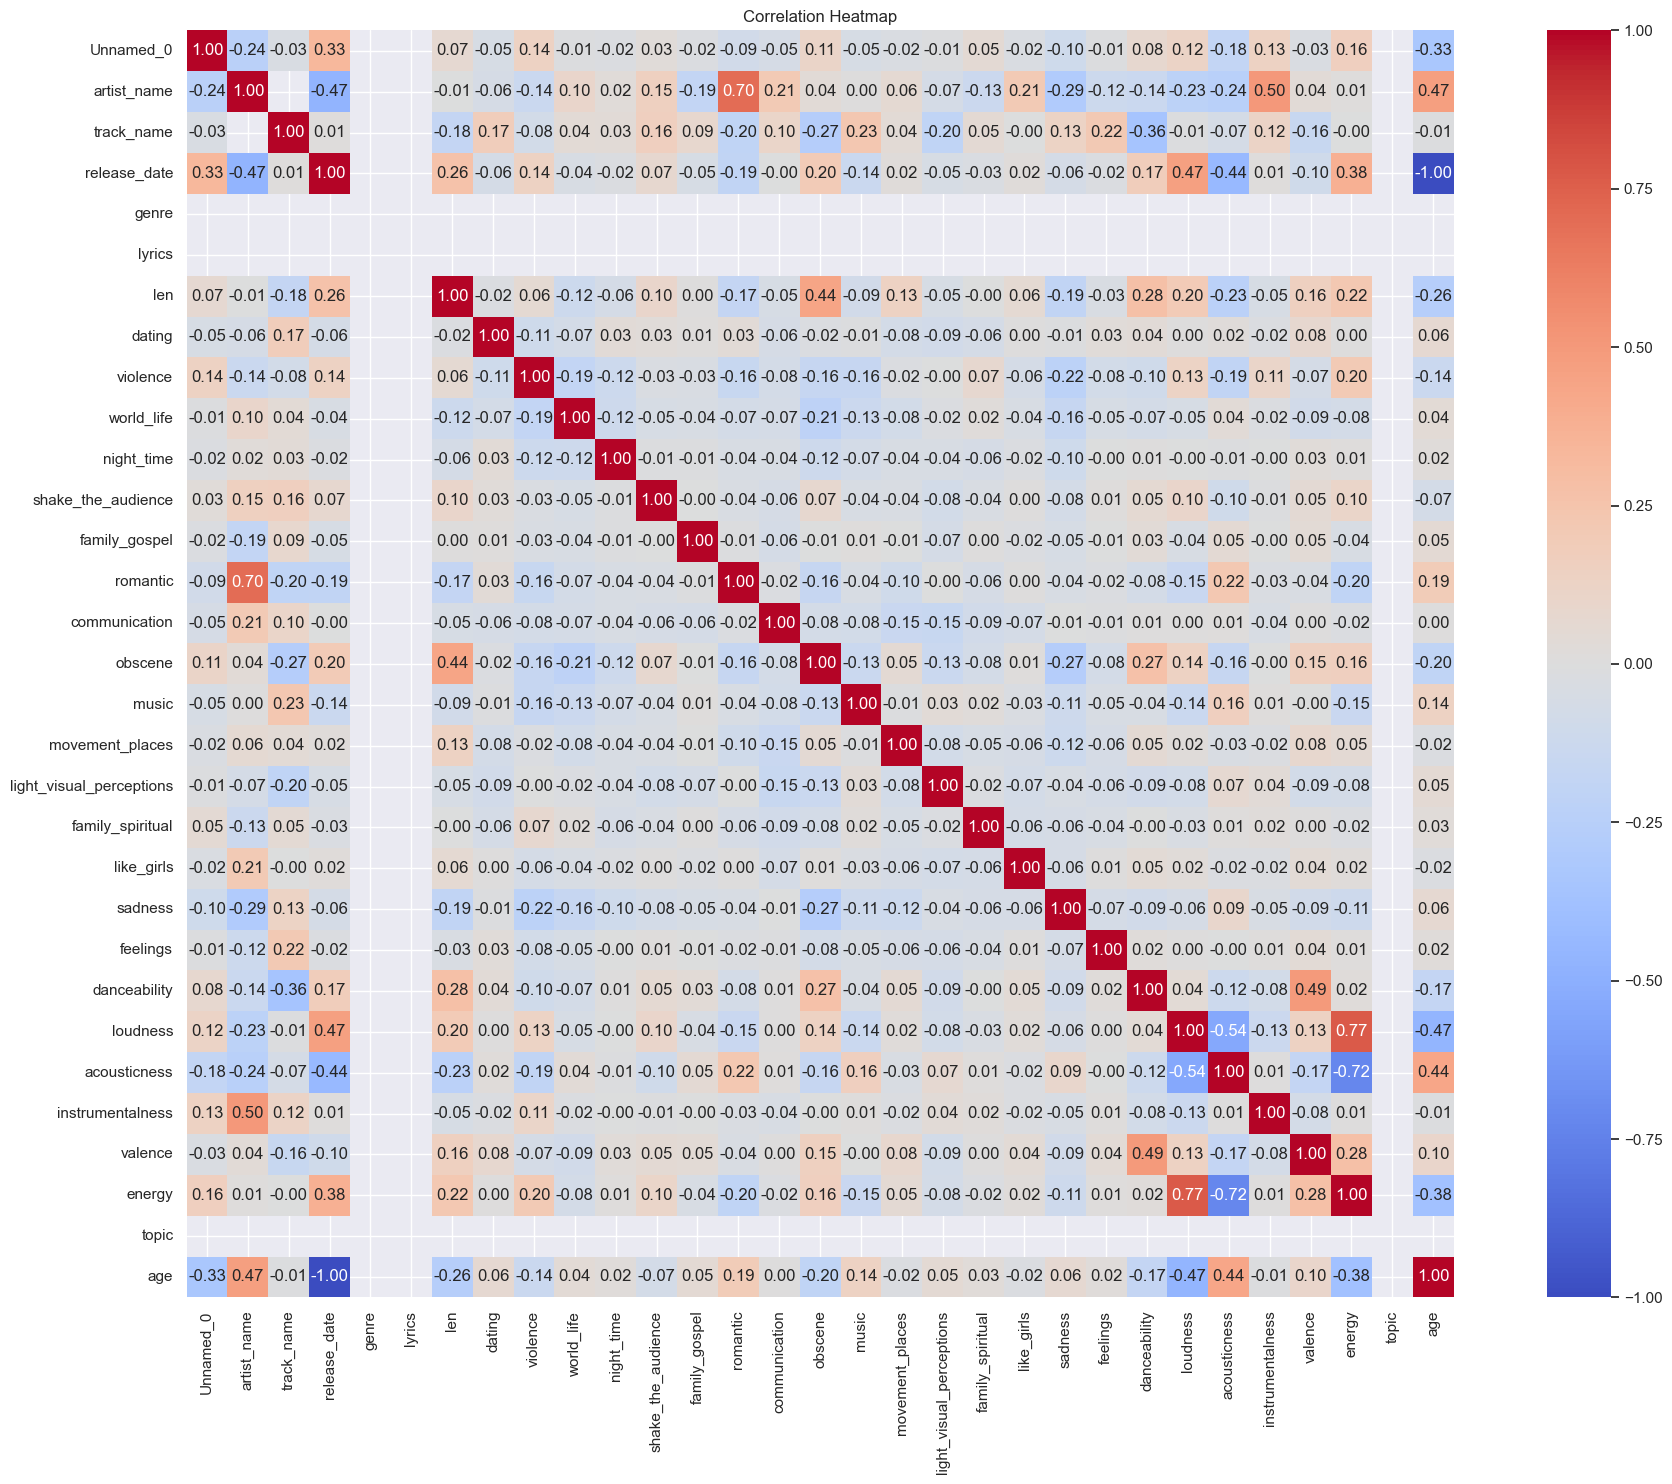

In [30]:
# Visualization of correlations using a heatmap 
#Adding plt.figure(figsize=(20,15)) to enhance size and readability --> figsize as a tuple

corr = df.corr(numeric_only=True)

plt.figure(figsize=(20,15))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Correlation Heatmap')
plt.tight_layout()
plt.show()

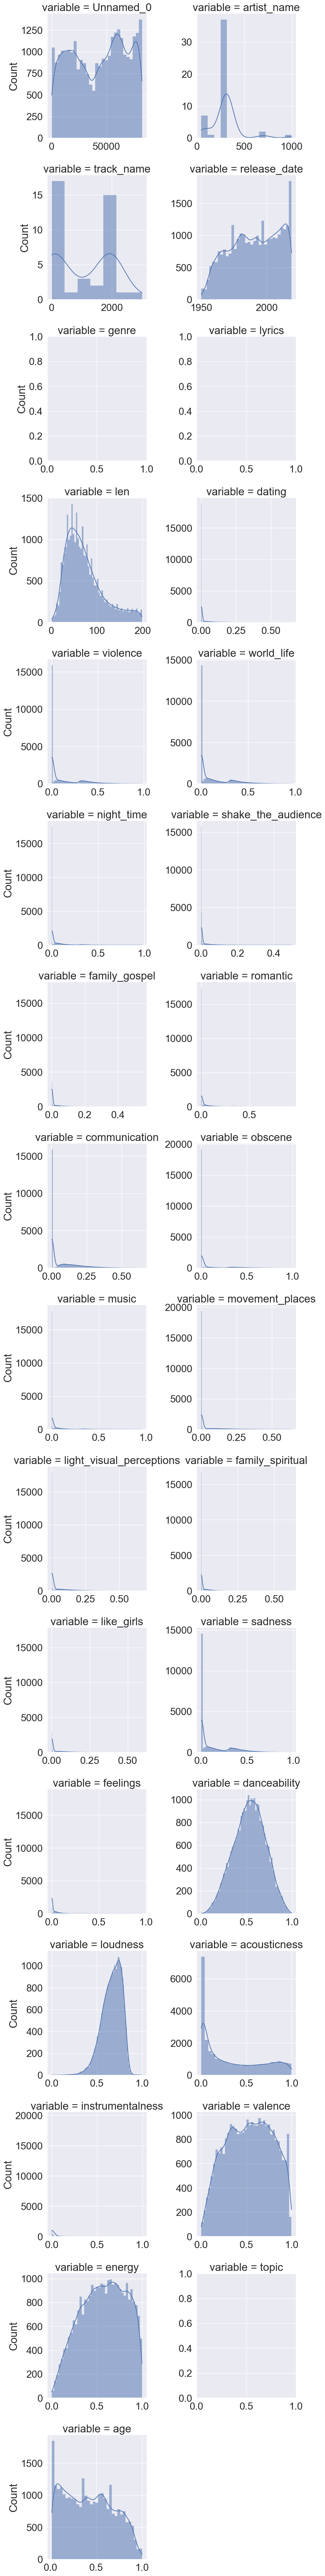

In [26]:
# Pair plot to get preliminary comparisons

plt.rcParams['font.size'] = 16
sns.set(font_scale=2)

compare_columns = df.select_dtypes(exclude=['object']).columns
df_long = df.melt(value_vars=compare_columns)
g = sns.displot(data=df_long, kde=True, x='value', common_bins=False, col='variable', col_wrap=2,
                facet_kws={'sharex': False, 'sharey': False})
g.set(xlabel='')
plt.show()

([0,
  1,
  2,
  3,
  4,
  5,
  6,
  7,
  8,
  9,
  10,
  11,
  12,
  13,
  14,
  15,
  16,
  17,
  18,
  19,
  20,
  21,
  22,
  23,
  24,
  25,
  26,
  27,
  28,
  29,
  30],
 [Text(0, 0, 'Unnamed_0'),
  Text(1, 0, 'artist_name'),
  Text(2, 0, 'track_name'),
  Text(3, 0, 'release_date'),
  Text(4, 0, 'genre'),
  Text(5, 0, 'lyrics'),
  Text(6, 0, 'len'),
  Text(7, 0, 'dating'),
  Text(8, 0, 'violence'),
  Text(9, 0, 'world_life'),
  Text(10, 0, 'night_time'),
  Text(11, 0, 'shake_the_audience'),
  Text(12, 0, 'family_gospel'),
  Text(13, 0, 'romantic'),
  Text(14, 0, 'communication'),
  Text(15, 0, 'obscene'),
  Text(16, 0, 'music'),
  Text(17, 0, 'movement_places'),
  Text(18, 0, 'light_visual_perceptions'),
  Text(19, 0, 'family_spiritual'),
  Text(20, 0, 'like_girls'),
  Text(21, 0, 'sadness'),
  Text(22, 0, 'feelings'),
  Text(23, 0, 'danceability'),
  Text(24, 0, 'loudness'),
  Text(25, 0, 'acousticness'),
  Text(26, 0, 'instrumentalness'),
  Text(27, 0, 'valence'),
  Text(28, 0

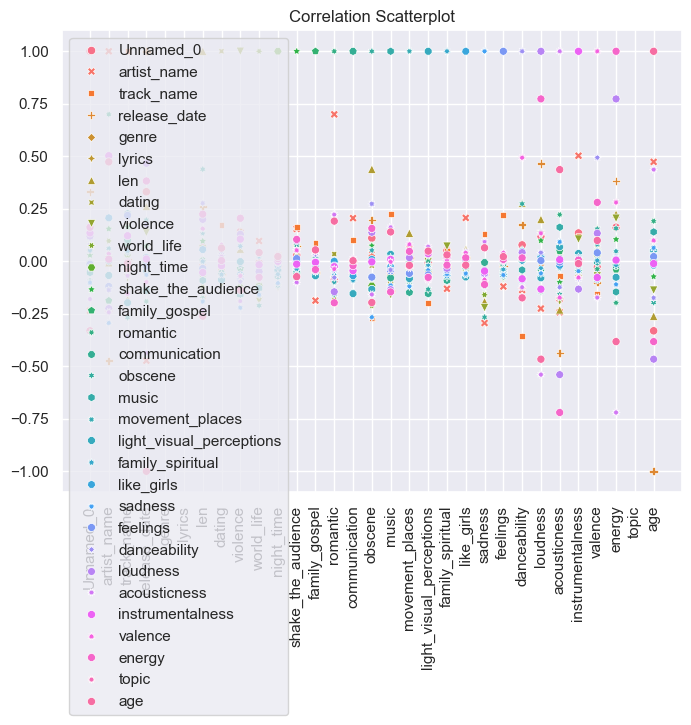

In [31]:
# Scatterplot of correlations
sns.set(rc={"figure.figsize":(8,6)}) 

sns.scatterplot(corr)
plt.title("Correlation Scatterplot")
plt.xticks(rotation=90)

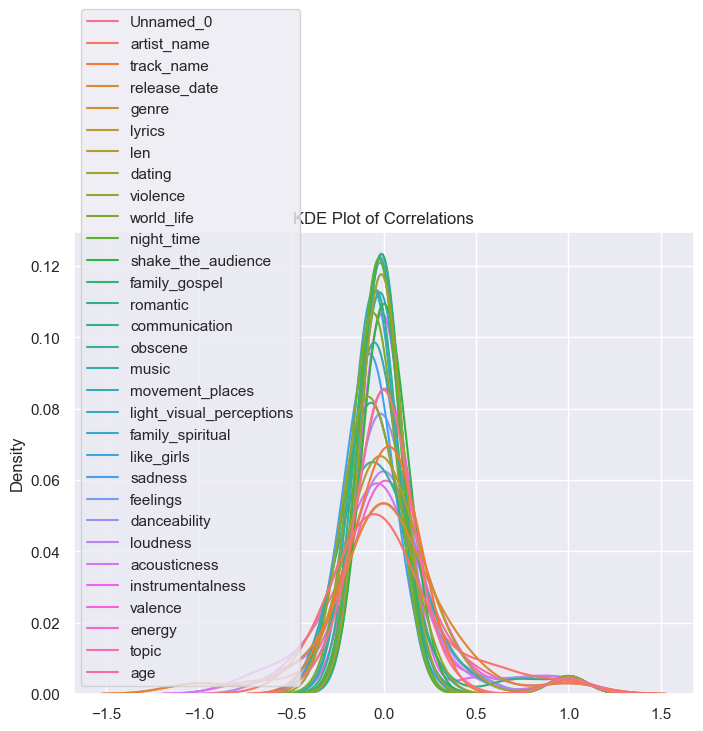

In [28]:
# KDE plot of correlations
sns.set(rc={"figure.figsize":(8,6)})

sns.kdeplot(corr)
plt.title("KDE Plot of Correlations")
plt.show()

---
### **8. The Plot Thickens**
Due to the large number of columns with numerical data, grouping variables that are similar in nature is the best course of action for more meaningful analysis. Tentative groups include:    
- Relationships | (word)    
- Emotions | (ie sadness)     
- Objective measures | (ie loudness)    
- Subjective measures | (ie violence)    
- Cosmos | (ie nighttime, light)    

In [ ]:
# Due to the large number of columns with numeric data, will group variables that are similar in nature

# Groups (tentative): relationships; objective measures (ie loudness); subjective measures (ie valence)



In [ ]:
# Iterate through columns to create boxplots for each numeric column against genre
for column in df.select_dtypes(exclude=['object']).columns:
    plt.figure(figsize=(14,7))
    sns.boxplot(x='genre', y=column, data=df)
    plt.ylim(0, 300000)    # Flag threshold
    plt.title(f"Music By Genre: {column}")
    plt.show()  

---
### **9. Hypothesis**